In [42]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('sales_data.csv')
df.head()

,OrderID,OrderDate,Region,Salesperson,Product,Category,Units,UnitPrice
0,1023,2025-01-24,North,RAVI KUMAR,Office Chair,Furniture,11.0,6500
1,1134,2025-03-29,North,Ananya Rao,Bookshelf,Furniture,2.0,4200
2,1115,2025-03-18,West,Rohan Shah,Notebook Set,Stationery,12.0,350
3,1077,2025-06-08,South,Divya Sharma,Office Chair,Furniture,3.0,6500
4,1009,2025-06-04,East,Sneha Das,Bookshelf,Furniture,9.0,4200


In [43]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      183 non-null    int64  
 1   OrderDate    183 non-null    object 
 2   Region       183 non-null    object 
 3   Salesperson  183 non-null    object 
 4   Product      183 non-null    object 
 5   Category     183 non-null    object 
 6   Units        174 non-null    float64
 7   UnitPrice    183 non-null    int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 11.6+ KB


,OrderID,Units,UnitPrice
count,183.000000,174.000000,183.000000
mean,1089.874317,6.534483,10835.939891
std,52.060621,3.580045,19291.238526
min,1001.000000,1.000000,120.000000
25%,1045.500000,3.000000,350.000000
50%,1090.000000,7.000000,2999.000000
75%,1134.500000,10.000000,15500.000000
max,1180.000000,12.000000,68000.000000


In [44]:
df['Region'] = df['Region'].str.strip().str.title()
df['Salesperson'] = df['Salesperson'].str.strip().str.title()
df['Product'] = df['Product'].str.strip().str.title()
df['Category'] = df['Category'].str.strip().str.title()

In [45]:
df['Units'] = df['Units'].fillna(0)

In [46]:
print("Before:", len(df))
df = df.drop_duplicates()
print("After:", len(df))

Before: 183
After: 180


In [47]:
df = df.reset_index(drop=True)

In [48]:
df['Sales'] = df['Units'] * df['UnitPrice']

In [49]:
total_sales = df['Sales'].sum()
total_units = df['Units'].sum()
total_orders = df['OrderID'].nunique()
avg_order_value = total_sales / total_orders
print(f"Total Sales: {total_sales:,.0f}")
print(f"Total Units: {total_units:,.0f}")
print(f"Total Orders: {total_orders}")
print(f"Avg Order Value: {avg_order_value:,.0f}")

Total Sales: 9,053,158
Total Units: 1,129
Total Orders: 180
Avg Order Value: 50,295


In [50]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(sales_by_region)

Region
West     2933144.0
North    2680273.0
South    2042877.0
East     1396864.0
Name: Sales, dtype: float64


In [51]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(sales_by_category)

Category
Electronics    6296288.0
Furniture      2683000.0
Stationery       73870.0
Name: Sales, dtype: float64


In [52]:
sales_by_salesperson = df.groupby('Salesperson')['Sales'].sum().sort_values(ascending=False)
print(sales_by_salesperson)

Salesperson
Ravi Kumar      1728152.0
Priya Mehta     1512305.0
Rohan Shah      1420839.0
Karthik Iyer    1391064.0
Ananya Rao       952121.0
Amit Ghosh       895307.0
Divya Sharma     651813.0
Sneha Das        501557.0
Name: Sales, dtype: float64


In [53]:
top_region = sales_by_region.idxmax()
print(f"Top Region: {top_region}")

Top Region: West


In [54]:
top_salesperson = sales_by_salesperson.idxmax()
print(f"Top Salesperson: {top_salesperson}")

Top Salesperson: Ravi Kumar


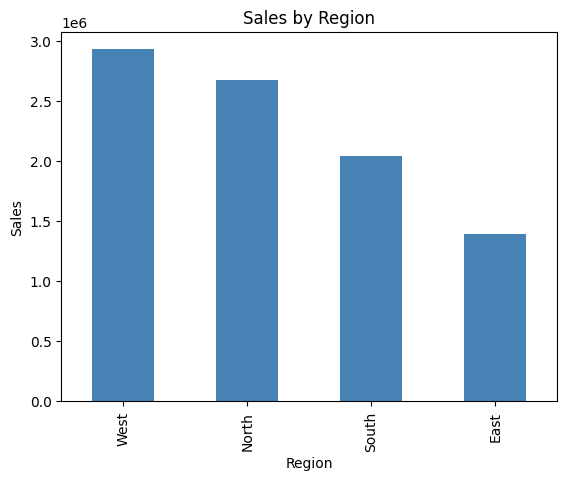

In [55]:
sales_by_region.plot(kind='bar', color='steelblue')
plt.title('Sales by Region')
plt.ylabel('Sales')
plt.xlabel('Region')
plt.show()

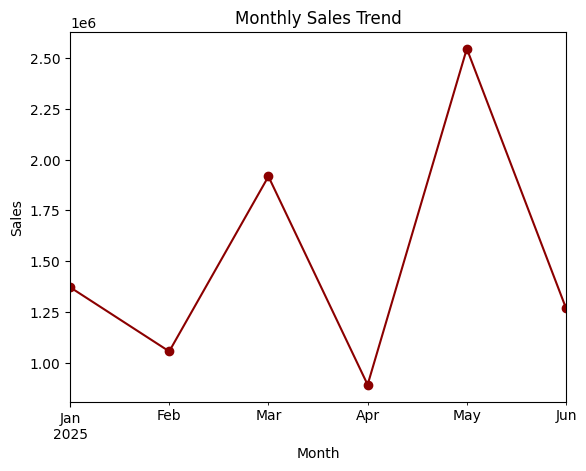

In [56]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Month'] = df['OrderDate'].dt.to_period('M')
sales_by_month = df.groupby('Month')['Sales'].sum()
sales_by_month.plot(kind='line', marker='o', color='darkred')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.xlabel('Month')
plt.show()

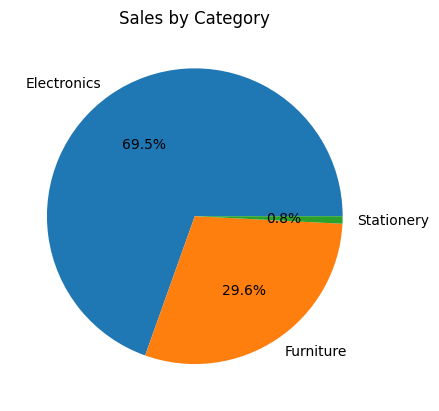

In [57]:
sales_by_category = df.groupby('Category')['Sales'].sum()
sales_by_category.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Category')
plt.ylabel('')
plt.show()

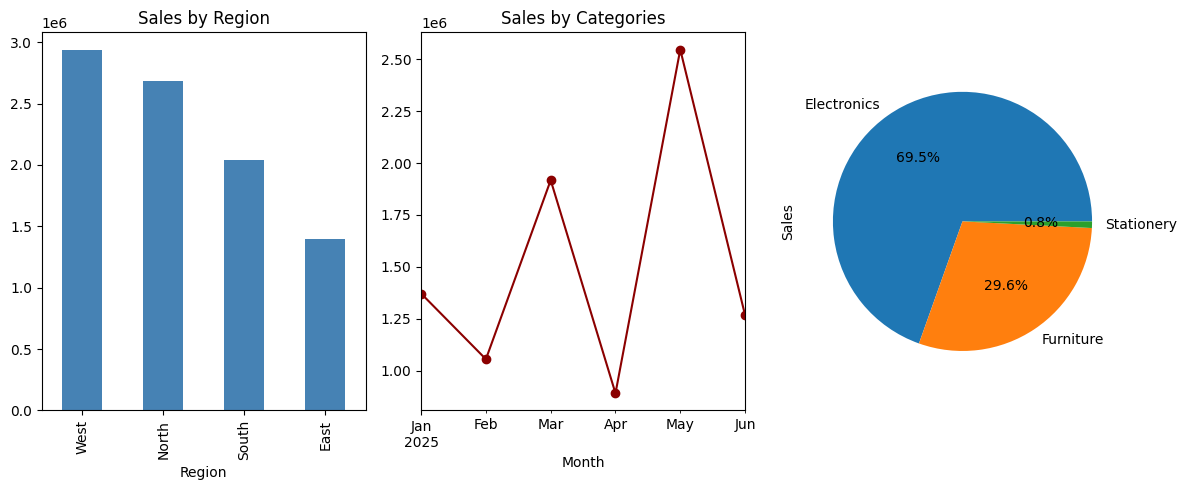

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sales_by_region.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Sales by Region')

sales_by_month.plot(kind='line', marker='o', ax=axes[1], color='darkred')
axes[1].set_title('Monthly Sales Trend')

sales_by_category.plot(kind='pie', autopct='%1.1f%%',ax=axes[2])
axes[1].set_title('Sales by Categories')

plt.tight_layout()
plt.show()